# Data load from drive
 

In [1]:
import sys
import os 
from tqdm import tqdm
from rasterio.enums import Resampling
import glob

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added:", PROJECT_ROOT)


Project root added: c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj


In [2]:
# data path
DRIVE_DIR = r"H:\My Drive\satelite_project\soil_classification"

DATASET_ROOT = "../Dataset/soil_type_classification"

LOCAL_PATCH_DIR = os.path.join(DATASET_ROOT, "patches")
os.makedirs(LOCAL_PATCH_DIR, exist_ok=True)
print("Patches will be saved in:", LOCAL_PATCH_DIR)

Patches will be saved in: ../Dataset/soil_type_classification\patches


### see metadata of satelite images
----------------------------------------------

In [3]:
from utils.soil_type_classification.document_stat import generate_scene_metadata

for soil_type in os.listdir(DRIVE_DIR):
    soil_path = os.path.join(DRIVE_DIR, soil_type)

    if not os.path.isdir(soil_path):
        continue

    for scene_name in os.listdir(soil_path):
        scene_dir = os.path.join(soil_path, scene_name)

        if os.path.isdir(scene_dir):
            generate_scene_metadata(DRIVE_DIR, soil_type, scene_name)

In [5]:
from utils.soil_type_classification.document_stat import verify_dataset_integrity

integrity_report = verify_dataset_integrity(DRIVE_DIR)

if not integrity_report:
    print("All JP2 files are valid.")
else:
    print("Corrupted files detected:")
    for scene, files in integrity_report.items():
        print(scene, "->", files)

All JP2 files are valid.


### Document statistics: min/max values, mean, std per band
-----------------------------------------------------------------------------------

In [3]:
from utils.soil_type_classification.document_stat import compute_scene_band_statistics

for soil_type in os.listdir(DRIVE_DIR):
    soil_path = os.path.join(DRIVE_DIR, soil_type)

    if not os.path.isdir(soil_path):
        continue

    for scene_name in os.listdir(soil_path):
        scene_dir = os.path.join(soil_path, scene_name)

        if not os.path.isdir(scene_dir):
            continue

        print(f"\nSoil: {soil_type} | Scene: {scene_name}")
        stats = compute_scene_band_statistics(scene_dir)
        print(stats)



Soil: black | Scene: scene_1
{'T43QDB_20251229T053139_B02_10m': {'min': 0.0, 'max': 20464.0, 'mean': 1533.3099838255348, 'std': 215.8133220907808}, 'T43QDB_20251229T053139_B03_10m': {'min': 0.0, 'max': 17968.0, 'mean': 1744.5500738302128, 'std': 241.1636792803094}, 'T43QDB_20251229T053139_B04_10m': {'min': 0.0, 'max': 14920.0, 'mean': 1913.2308375552834, 'std': 400.24490949073146}, 'T43QDB_20251229T053139_B08_10m': {'min': 0.0, 'max': 17904.0, 'mean': 3176.0496200078965, 'std': 705.7348533815544}, 'T43QDB_20251229T053139_B11_20m': {'min': 865.0, 'max': 16676.0, 'mean': 2978.410524882134, 'std': 619.1362918480075}, 'T43QDB_20251229T053139_SCL_20m': {'min': 2.0, 'max': 10.0, 'mean': 4.805014316475393, 'std': 0.4295168088052381}}

Soil: black | Scene: scene_2
{'T43QDC_20251229T053139_B02_10m': {'min': 0.0, 'max': 22176.0, 'mean': 1530.4712863842522, 'std': 209.51111927278694}, 'T43QDC_20251229T053139_B03_10m': {'min': 0.0, 'max': 20576.0, 'mean': 1734.7336371312638, 'std': 237.4659289285

KeyboardInterrupt: 

In [3]:
import os

def find_band_file(scene_dir, band_code):
    """
    Finds JP2 file containing a specific band (e.g., B02, B03, B04, B08)
    """
    for file in os.listdir(scene_dir):
        if file.endswith(".jp2") and f"_{band_code}_" in file:
            return os.path.join(scene_dir, file)
    raise FileNotFoundError(f"{band_code} not found in {scene_dir}")


In [4]:
import numpy as np
import rasterio

def load_rgb_from_scene(scene_dir):
    """
    Loads RGB image from Sentinel-2 JP2 files with standard naming.
    """

    red_path   = find_band_file(scene_dir, "B04")
    green_path = find_band_file(scene_dir, "B03")
    blue_path  = find_band_file(scene_dir, "B02")

    with rasterio.open(red_path) as r:
        red = r.read(1).astype(np.float32)
    with rasterio.open(green_path) as g:
        green = g.read(1).astype(np.float32)
    with rasterio.open(blue_path) as b:
        blue = b.read(1).astype(np.float32)

    rgb = np.stack([red, green, blue], axis=-1)

    # Visualization normalization
    rgb = rgb / np.percentile(rgb, 99)
    rgb = np.clip(rgb, 0, 1)

    return rgb

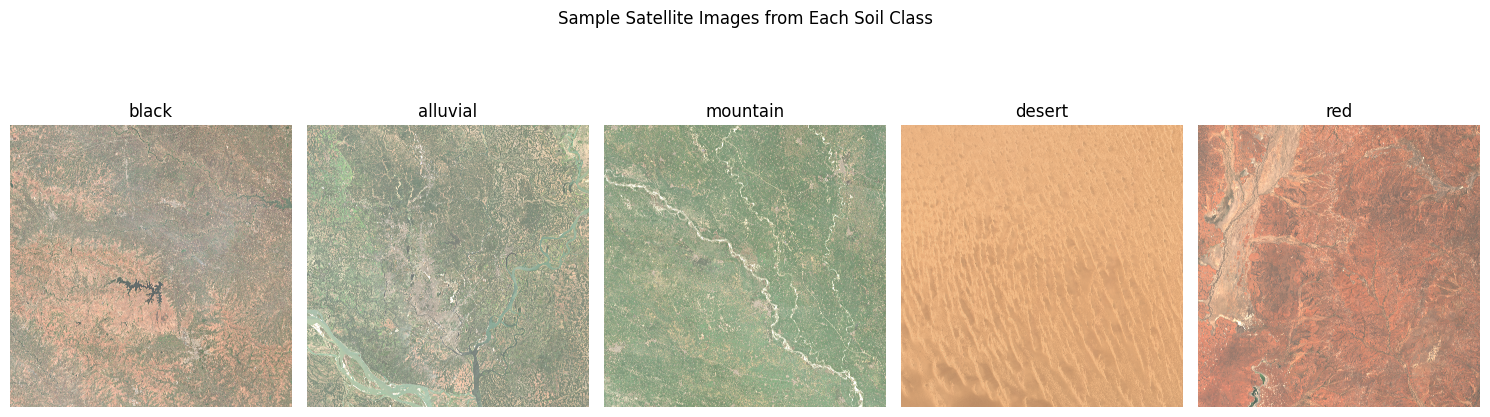

In [10]:
import matplotlib.pyplot as plt

soil_types = os.listdir(DRIVE_DIR)
plt.figure(figsize=(15, 5))
plt_idx = 1

for soil_type in soil_types:
    soil_path = os.path.join(DRIVE_DIR, soil_type)
    scene_names = os.listdir(soil_path)

    if not scene_names:
        continue

    # Load the first scene for this soil type
    scene_name = scene_names[0]
    scene_dir = os.path.join(soil_path, scene_name)
    rgb_image = load_rgb_from_scene(scene_dir)

    plt.subplot(1, len(soil_types), plt_idx)
    plt.imshow(rgb_image)
    plt.title(soil_type)
    plt.axis('off')
    plt_idx += 1

plt.suptitle("Sample Satellite Images from Each Soil Class")
plt.tight_layout()
plt.show()

# DaTA Preprocessing


### Image preproccessing
--------------------------------------

In [11]:
# Radiometric Correction

from utils.soil_type_classification.image_preproccessing import read_and_normalize_band


soil_types = ["black","alluvial", "red", "desert", "mountain"]

bands_required = ["B02", "B03", "B04", "B08"]

for soil in soil_types:
    soil_dir = os.path.join(DRIVE_DIR, soil)
    
    for scene_name in os.listdir(soil_dir):
        scene_path = os.path.join(soil_dir, scene_name)
        
        for file in os.listdir(scene_path):
            if file.endswith(".jp2") and any(b in file for b in bands_required):
                jp2_path = os.path.join(scene_path, file)
                normalized_band = read_and_normalize_band(jp2_path)


In [5]:
from utils.soil_type_classification.image_preproccessing import (
    read_and_resample_scl,
    generate_cloud_mask,
    apply_cloud_mask,
    read_and_normalize_band
)
import numpy as np

soil_types = ["black","alluvial", "red", "desert", "mountain"]
bands_required = ["B02", "B03", "B04", "B08"]

for soil in soil_types:
    soil_dir = os.path.join(DRIVE_DIR, soil)

    for scene_name in os.listdir(soil_dir):
        scene_path = os.path.join(soil_dir, scene_name)

        # ---- Read SCL ONCE ----
        scl_file = [f for f in os.listdir(scene_path) if "SCL" in f][0]
        scl_path = os.path.join(scene_path, scl_file)

        band_list = []

        for band_name in bands_required:
            band_file = [f for f in os.listdir(scene_path) if band_name in f][0]
            band_path = os.path.join(scene_path, band_file)

            band = read_and_normalize_band(band_path)
            band_list.append(band)

        # ---- Stack bands (H, W, C) ----
        band_stack = np.stack(band_list, axis=-1)

        # ---- Resample SCL ONCE ----
        scl_10m = read_and_resample_scl(
            scl_path,
            target_shape=band_stack.shape[:2]
        )

        cloud_mask = generate_cloud_mask(scl_10m)

        # ---- Apply cloud mask to ALL bands ----
        band_stack[cloud_mask] = 0

        
        # QUALITY FILTERING (HERE)
       
        cloud_ratio = np.sum(cloud_mask) / cloud_mask.size
        valid_ratio = np.count_nonzero(band_stack) / band_stack.size
        variance = np.var(band_stack)

        if cloud_ratio > 0.4:
            continue  

        if valid_ratio < 0.7:
            continue  
        if variance < 0.005:
            continue 

### Patch extraction (patch size, stride, overlapping)
---------------------------------------------------------

In [5]:
PATCH_SIZE = 128
STRIDE = 64

PATCH_OUTPUT_DIR = "../Dataset/soil_type_classification/patches"

VALID_EXT = ".jp2"

In [6]:
import sys
sys.path.append("../src")

from utils.soil_type_classification.patch import process_dataset

process_dataset(
    dataset_dir=DRIVE_DIR,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    output_dir=PATCH_OUTPUT_DIR,
    valid_ext=VALID_EXT
)


=== Processing soil class: desert ===


desert scenes:  25%|██▌       | 1/4 [11:48<35:25, 708.38s/it]

[SCENE] Soil: desert | Scene: scene_4 | Patches created: 28900


desert scenes:  50%|█████     | 2/4 [29:52<30:58, 929.28s/it]

[SCENE] Soil: desert | Scene: scene_2 | Patches created: 28900


...

[SCENE] Soil: red | Scene: scene_5 | Patches created: 28900


red scenes:  80%|████████  | 4/5 [36:54<09:16, 556.05s/it]

[SCENE] Soil: red | Scene: scene_2 | Patches created: 28900


red scenes: 100%|██████████| 5/5 [45:40<00:00, 548.10s/it]

[SCENE] Soil: red | Scene: scene_4 | Patches created: 28900
[SUMMARY] Soil: red | Total patches: 144500

[DATASET COMPLETE] Total patches created: 375700


# Model architecture Design


# Training Strategy


# Model Evaluation

# Model Optimization & Improvement

# Deployment Preperation

# Documentation & Reporting

In [2]:
import rasterio

with rasterio.open("13.tif") as src:
    print(src.bounds)
    print(src.crs)


BoundingBox(left=0.0, bottom=256.0, right=256.0, top=0.0)
None


c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
